# n_steps Sensitivity Analysis — Per-Group TARP & MIRA

Compares four inference conditions on a random 100-complex PoseBusters subset:

| Condition | Inference steps | Mode |
|-----------|----------------|------|
| **sde_10** | 10 | SDE (stochastic) |
| **sde_20** | 20 | SDE — baseline (from pb_evaluate_v2_merged) |
| **sde_50** | 50 | SDE (stochastic) |
| **ode_20** | 20 | ODE (deterministic) |

Analyses distribution quality **separately per diffusion group**:
- **Translation** (R³): where does the ligand centroid land?
- **Rotation** (SO(3)): how is the ligand oriented?
- **Torsion** (T^k): what are the internal dihedral angles?

Precomputed by `diffdock_sensitivity_group_eval.sh` → `sensitivity_ode_nsteps_v3/<cond>/metrics/group_eval/`.

## 0 · Setup

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from molcalib.tarp import ecp_from_fractions, bootstrap_ecp, plot_ecp
from molcalib.mira import mira_null

# ── Paths ─────────────────────────────────────────────────────────────────────
RDS      = "/home/qf226/rds/hpc-work"
SENS_ROOT = f"{RDS}/results/DiffDock/sensitivity_ode_nsteps_v3"
FIGDIR    = os.path.abspath("../figures/sensitivity_n_steps")
os.makedirs(FIGDIR, exist_ok=True)

CONDITIONS = {
    "sde_10": {"label": "sde_10  (10 steps, SDE)",  "color": "C0", "linestyle": "-"},
    "sde_20": {"label": "sde_20  (20 steps, SDE)",  "color": "C1", "linestyle": "-"},
    "sde_50": {"label": "sde_50  (50 steps, SDE)",  "color": "C2", "linestyle": "-"},
    "ode_20": {"label": "ode_20  (20 steps, ODE)",  "color": "C3", "linestyle": "--"},
}

GROUPS = ["translation", "rotation", "torsion"]
GROUP_LABELS = ["Translation (Å)", "Rotation (rad)", "Torsion RMS (rad)"]

MIRA_NULL = mira_null(40)
print(f"MIRA null reference (S=40): {MIRA_NULL:.4f}")
print("Setup complete.")

MIRA null reference (S=40): 0.6833
Setup complete.


## 1 · Load precomputed data

In [2]:
def load_condition(cond):
    """Load all group-eval .npy outputs for one condition."""
    ge = f"{SENS_ROOT}/{cond}/metrics/group_eval"
    d = {}
    for grp in GROUPS:
        tarp_path = f"{ge}/tarp_fractions_{grp}.npy"
        dist_key  = "torsion_rms" if grp == "torsion" else grp
        dist_path = f"{ge}/distances_{dist_key}.npy"
        mira_path = f"{ge}/mira_scores_{grp}.npy"
        d[grp] = {
            "tarp": np.load(tarp_path) if os.path.exists(tarp_path) else None,
            "dist": np.load(dist_path) if os.path.exists(dist_path) else None,
            "mira": np.load(mira_path) if os.path.exists(mira_path) else None,
        }
    names_path = f"{ge}/complex_names.npy"
    d["names"] = np.load(names_path, allow_pickle=True) if os.path.exists(names_path) else None
    n_bonds_path = f"{ge}/n_rot_bonds.npy"
    d["n_rot_bonds"] = np.load(n_bonds_path) if os.path.exists(n_bonds_path) else None
    return d


data = {cond: load_condition(cond) for cond in CONDITIONS}

for cond, d in data.items():
    parts = []
    for grp in GROUPS:
        t = d[grp]["tarp"]
        parts.append(f"{grp}={t.shape if t is not None else 'MISSING'}")
    print(f"{cond}: {', '.join(parts)}")

sde_10: translation=(305, 100), rotation=(305, 100), torsion=(305, 100)
sde_20: translation=(305, 100), rotation=(305, 100), torsion=(305, 100)
sde_50: translation=(305, 100), rotation=(305, 100), torsion=(305, 100)
ode_20: translation=(305, 100), rotation=(305, 100), torsion=(305, 100)


## 2 · RMSD accuracy

Top-1 RMSD metrics computed from `metrics/top1_rmsd.npy` for each condition.

In [3]:
import pandas as pd

STEPS = {"sde_10": 10, "sde_20": 20, "sde_50": 50, "ode_20": 20}
MODES = {"sde_10": "SDE", "sde_20": "SDE", "sde_50": "SDE", "ode_20": "ODE"}

rows = []
for cond in CONDITIONS:
    top1   = np.load(f"{SENS_ROOT}/{cond}/metrics/top1_rmsd.npy")
    rmsds  = np.load(f"{SENS_ROOT}/{cond}/metrics/rmsds.npy")  # (N, S)
    oracle = np.nanmin(rmsds, axis=1)
    rows.append({
        "Condition":        cond,
        "Steps":            STEPS[cond],
        "Mode":             MODES[cond],
        "RMSD<2Å (%)": round((top1   < 2).mean() * 100, 1),
        "RMSD<5Å (%)": round((top1   < 5).mean() * 100, 1),
        "Median RMSD (Å)": round(float(np.median(top1)), 2),
        "Oracle<2Å (%)": round((oracle < 2).mean() * 100, 1),
    })

rmsd_table = pd.DataFrame(rows).set_index("Condition")

rmsd_table.style.format(precision=1) \
    .highlight_max(subset=["RMSD<2Å (%)", "RMSD<5Å (%)", "Oracle<2Å (%)"], color="lightgreen") \
    .highlight_min(subset=["Median RMSD (Å)"], color="lightgreen")

,Steps,Mode,RMSD<2Å (%),RMSD<5Å (%),Median RMSD (Å),Oracle<2Å (%)
Condition,,,,,,
sde_10,10,SDE,21.3,64.3,nan,40.7
sde_20,20,SDE,52.8,74.4,1.7,61.6
sde_50,50,SDE,50.5,73.4,2.0,65.9
ode_20,20,ODE,49.2,72.5,nan,65.9


## 3 · Per-group TARP — ECP curves

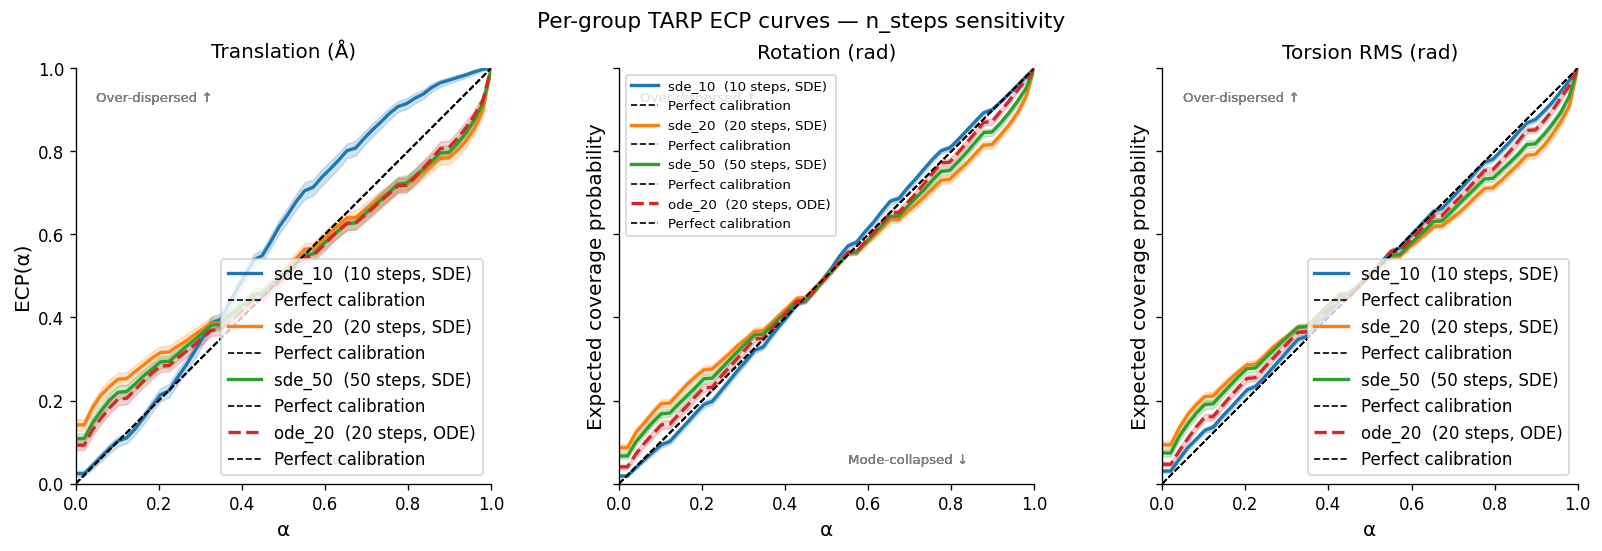

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.suptitle("Per-group TARP ECP curves — n_steps sensitivity", fontsize=13)

for ax, grp, glabel in zip(axes, GROUPS, GROUP_LABELS):
    for cond, meta in CONDITIONS.items():
        fracs = data[cond][grp]["tarp"]
        if fracs is None:
            continue
        fracs = fracs[~np.isnan(fracs).any(axis=1)]
        ecp, alpha = ecp_from_fractions(fracs)
        boot = bootstrap_ecp(fracs, n_bootstrap=500)
        plot_ecp(
            ecp, alpha, ax=ax,
            label=meta["label"],
            color=meta["color"],
            bootstrap_ecps=boot,
            linestyle=meta.get("linestyle", "-"),
        )

    ax.set_title(glabel)
    ax.set_xlabel("α")

axes[0].set_ylabel("ECP(α)")
axes[1].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGDIR}/tarp_ecp_per_group.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Per-group MIRA scores

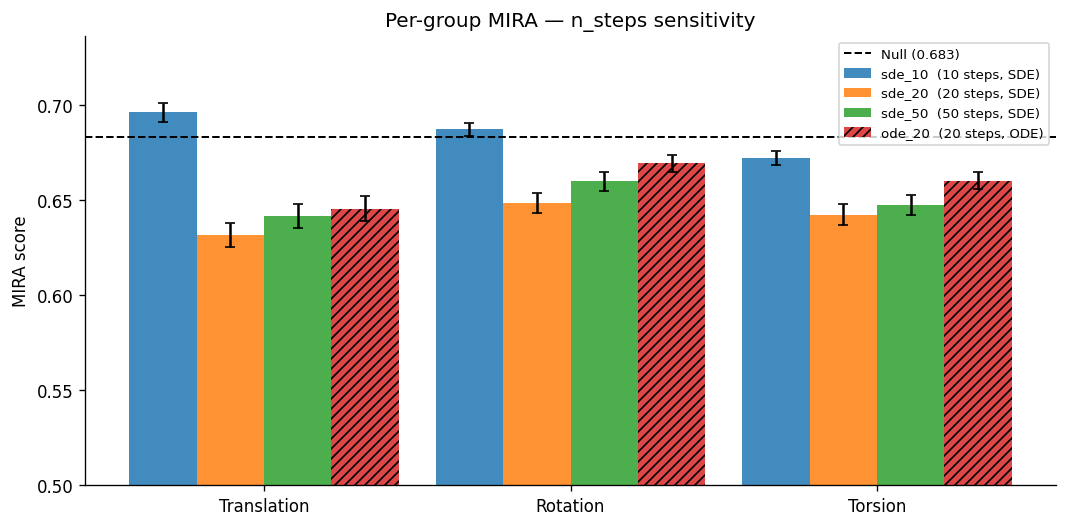

In [5]:
n_conds = len(CONDITIONS)
n_groups = len(GROUPS)
x = np.arange(n_groups)
width = 0.22
offsets = np.linspace(-(n_conds - 1) / 2 * width, (n_conds - 1) / 2 * width, n_conds)

fig, ax = plt.subplots(figsize=(9, 4.5))

for i, (cond, meta) in enumerate(CONDITIONS.items()):
    means, errs = [], []
    for grp in GROUPS:
        scores = data[cond][grp]["mira"]
        if scores is None or len(scores) == 0:
            means.append(np.nan)
            errs.append(0)
        else:
            scores = scores[~np.isnan(scores)]
            means.append(scores.mean())
            boot = [np.random.choice(scores, len(scores), replace=True).mean() for _ in range(500)]
            errs.append(np.std(boot) * 1.96)

    hatch = '////' if meta.get('linestyle') == '--' else None
    ax.bar(
        x + offsets[i], means, width,
        label=meta["label"], color=meta["color"],
        yerr=errs, capsize=3, alpha=0.85,
        hatch=hatch,
    )

ax.axhline(MIRA_NULL, color="black", linestyle="--", linewidth=1.2, label=f"Null ({MIRA_NULL:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(["Translation", "Rotation", "Torsion"])
ax.set_ylabel("MIRA score")
ax.set_title("Per-group MIRA — n_steps sensitivity")
ax.legend(fontsize=8)
ax.set_ylim(0.5, None)

plt.tight_layout()
plt.savefig(f"{FIGDIR}/mira_per_group.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Distance distributions

Violin plots of per-sample distances from crystal pose. Each violin shows the spread of DiffDock predictions for all complexes pooled. This reveals whether more steps increase or decrease how spread out the predictions are across each degree of freedom.

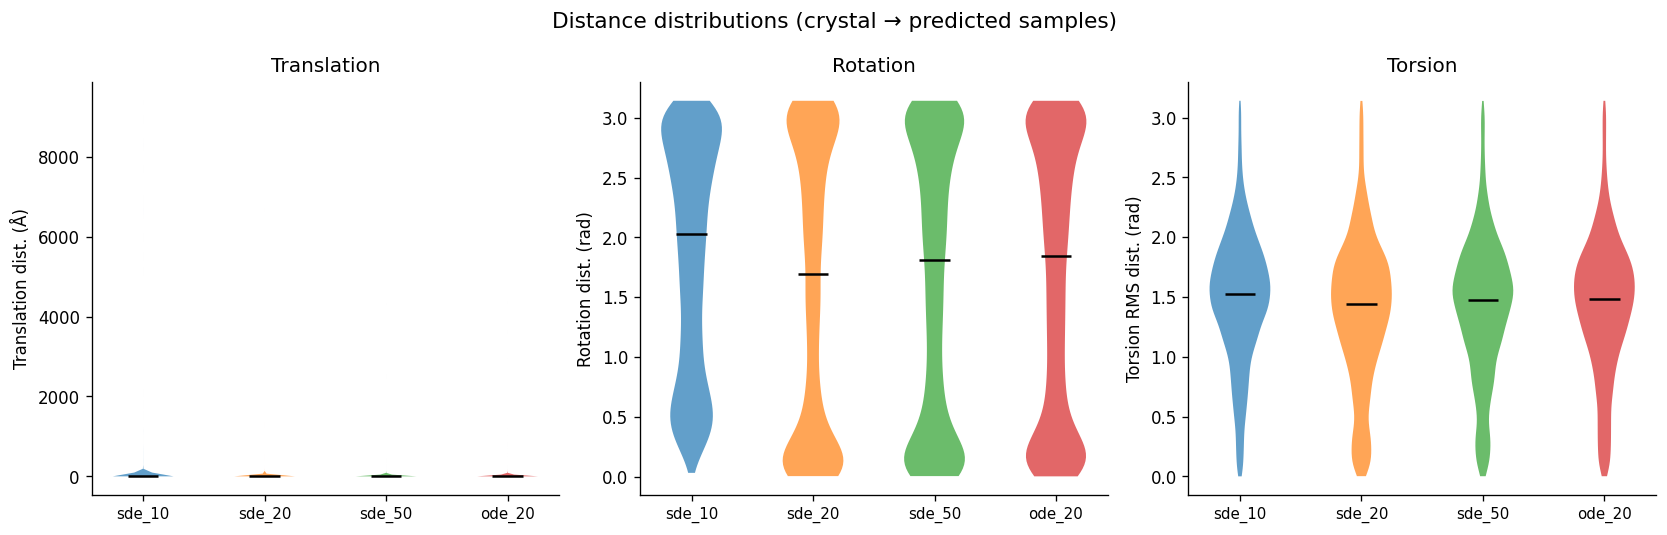

In [6]:
dist_keys   = ["translation", "rotation", "torsion"]
dist_labels = ["Translation dist. (Å)", "Rotation dist. (rad)", "Torsion RMS dist. (rad)"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Distance distributions (crystal → predicted samples)", fontsize=13)

for ax, grp, dlabel in zip(axes, dist_keys, dist_labels):
    violin_data = []
    tick_labels = []
    colors = []

    for cond, meta in CONDITIONS.items():
        dist = data[cond][grp]["dist"]
        if dist is None:
            continue
        # Flatten all samples across complexes; filter NaN and ±inf
        flat = dist.ravel()
        flat = flat[np.isfinite(flat) & (flat < 1e4)]
        violin_data.append(flat)
        tick_labels.append(meta["label"].split()[0])
        colors.append(meta["color"])

    if not violin_data:
        continue

    parts = ax.violinplot(violin_data, showmedians=True, showextrema=False)
    for pc, col in zip(parts["bodies"], colors):
        pc.set_facecolor(col)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.5)

    ax.set_xticks(range(1, len(tick_labels) + 1))
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylabel(dlabel)
    ax.set_title(grp.capitalize())

plt.tight_layout()
plt.savefig(f"{FIGDIR}/distance_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Summary table

In [7]:
rows = []
for cond, meta in CONDITIONS.items():
    row = {"Condition": cond}
    for grp in GROUPS:
        scores = data[cond][grp]["mira"]
        if scores is not None and len(scores):
            scores = scores[~np.isnan(scores)]
            row[f"MIRA_{grp[:3]}"] = round(float(scores.mean()), 4)
        else:
            row[f"MIRA_{grp[:3]}"] = None
    rows.append(row)

summary = pd.DataFrame(rows).set_index("Condition")
print(f"MIRA null = {MIRA_NULL:.4f}  (above null = over-dispersed, below = mode-collapsed)")
summary

MIRA null = 0.6833  (above null = over-dispersed, below = mode-collapsed)


,MIRA_tra,MIRA_rot,MIRA_tor
Condition,,,
sde_10,0.6961,0.6871,0.6722
sde_20,0.6315,0.6485,0.6423
sde_50,0.6415,0.6598,0.6476
ode_20,0.6454,0.6694,0.6602


## 7 · Flat symRMSD TARP — ECP curves

Global (non-per-group) TARP calibration using RMSD to crystal pose. K=1 reference point per complex.

In [8]:
# Load flat RMSD TARP fractions
tarp_rmsd = {}
for cond in CONDITIONS:
    p = f"{SENS_ROOT}/{cond}/metrics/tarp_fractions_symrmsd_K1.npy"
    tarp_rmsd[cond] = np.load(p) if os.path.exists(p) else None
    shape = tarp_rmsd[cond].shape if tarp_rmsd[cond] is not None else 'MISSING'
    print(f"{cond}: {shape}")


sde_10: (305, 1)


sde_20: (305, 1)
sde_50: (305, 1)
ode_20: (277, 1)


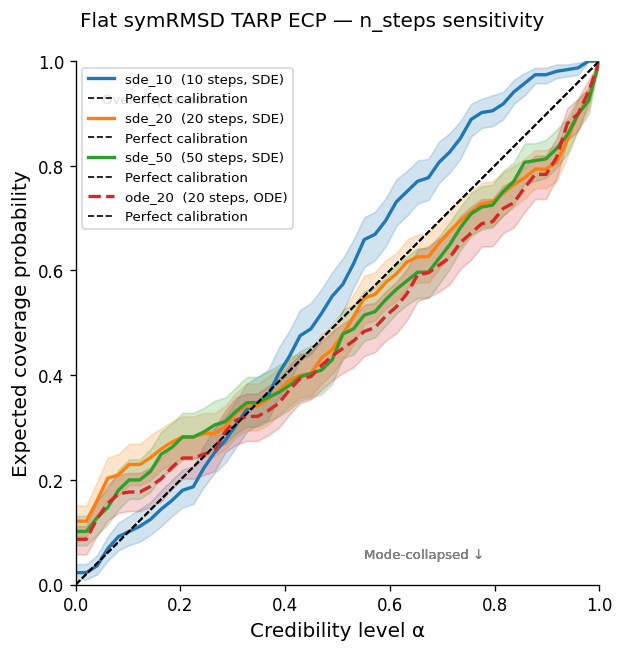

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
fig.suptitle("Flat symRMSD TARP ECP — n_steps sensitivity", fontsize=12)

for cond, meta in CONDITIONS.items():
    fracs = tarp_rmsd.get(cond)
    if fracs is None:
        continue
    fracs = fracs[~np.isnan(fracs).any(axis=1)]
    ecp, alpha = ecp_from_fractions(fracs)
    boot = bootstrap_ecp(fracs, n_bootstrap=500)
    plot_ecp(
        ecp, alpha, ax=ax,
        label=meta['label'],
        color=meta["color"],
        bootstrap_ecps=boot,
        linestyle=meta.get("linestyle", "-"),
    )

ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/tarp_ecp_symrmsd_flat.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Flat symRMSD MIRA scores

Global MIRA using RMSD as the distance metric. Each bar is the mean per-complex MIRA score; error bars are 95% CI via bootstrap.

In [10]:
# Load flat RMSD MIRA scores
mira_rmsd = {}
for cond in CONDITIONS:
    p = f"{SENS_ROOT}/{cond}/metrics/mira_scores_symrmsd.npy"
    mira_rmsd[cond] = np.load(p) if os.path.exists(p) else None
    n = len(mira_rmsd[cond]) if mira_rmsd[cond] is not None else 'MISSING'
    print(f"{cond}: {n}")


sde_10: 305
sde_20: 305
sde_50: 305
ode_20: 305


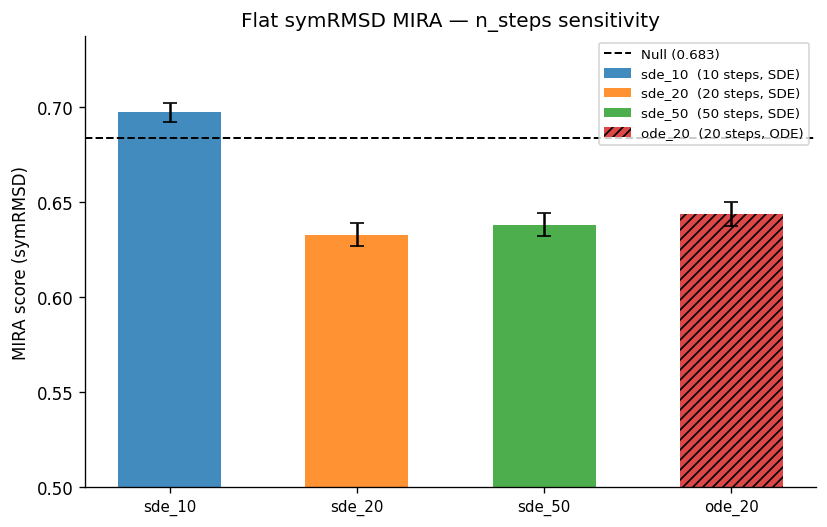

In [11]:
x = np.arange(len(CONDITIONS))
width = 0.55

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, (cond, meta) in enumerate(CONDITIONS.items()):
    scores = mira_rmsd.get(cond)
    if scores is None or len(scores) == 0:
        continue
    scores = scores[~np.isnan(scores)]
    mean = scores.mean()
    boot = [np.random.choice(scores, len(scores), replace=True).mean() for _ in range(500)]
    err = np.std(boot) * 1.96
    hatch = '////' if meta.get('linestyle') == '--' else None
    ax.bar(i, mean, width, label=meta["label"], color=meta["color"],
           yerr=err, capsize=4, alpha=0.85, hatch=hatch)

ax.axhline(MIRA_NULL, color="black", linestyle="--", linewidth=1.2,
           label=f"Null ({MIRA_NULL:.3f})")
ax.set_xticks(x)
ax.set_xticklabels([m["label"].split()[0] for m in CONDITIONS.values()], fontsize=9)
ax.set_ylabel("MIRA score (symRMSD)")
ax.set_title("Flat symRMSD MIRA — n_steps sensitivity")
ax.legend(fontsize=8)
ax.set_ylim(0.5, None)

plt.tight_layout()
plt.savefig(f"{FIGDIR}/mira_symrmsd_flat.png", dpi=150, bbox_inches="tight")
plt.show()
